In [1]:
# =============================================================================
# 04_multiplicity_ratio.ipynb
#
# Computes the SIDIS π+ multiplicity ratio R(zh) for LD2.
#
# WHAT THIS NOTEBOOK DOES:
#   1. Loads data, reco, gen yield CSVs from count_sidis_bins.py
#   2. Computes multiplicity M = N_pip / N_e per zh bin
#   3. Computes acceptance correction A(zh) = M_reco / M_gen
#   4. Computes corrected R(zh) = M_data / A(zh)
#   5. Plots R(zh) with statistical error bars
#
# HOW TO SWITCH CUT SETS:
#   Change CUT_SET in scripts/analysis_cuts.py, then rerun count_sidis_bins.py
#   to regenerate the CSVs. No changes needed in this notebook.
#
# CORRECTIONS STATUS:
#   Acceptance correction : APPLIED   (Reco/Gen)
#   ρ contamination       : NOT YET   (pending Fermi motion study)
#   Radiative correction  : NOT YET   (pending HAPRAD)
#   → Results are PRELIMINARY — flag as such in any presentation
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
from matplotlib.backends.backend_pdf import PdfPages

# ── Paths ─────────────────────────────────────────────────────────────────────
# LOCAL (Mac): change YIELDS_DIR to match your output directory
# iFarm:       change to /volatile/clas12/rg-d/<user>/parquet/yields/
YIELDS_DIR = '/Users/sumanshrestha/Desktop/Physics_Analysis/test_output/yields'  # <-- CHANGE THIS

DATA_CSV = os.path.join(YIELDS_DIR, 'data_LD2.csv')
RECO_CSV = os.path.join(YIELDS_DIR, 'reco_LD2.csv')
GEN_CSV  = os.path.join(YIELDS_DIR, 'gen_LD2.csv')

# ── Load CSVs ─────────────────────────────────────────────────────────────────
data = pd.read_csv(DATA_CSV)
reco = pd.read_csv(RECO_CSV)
gen  = pd.read_csv(GEN_CSV)

print(f'Data bins : {len(data)}')
print(f'Reco bins : {len(reco)}')
print(f'Gen  bins : {len(gen)}')
print(f'Columns   : {data.columns.tolist()}')

Data bins : 150
Reco bins : 150
Gen  bins : 150
Columns   : ['zh_lo', 'zh_hi', 'zh_mean', 'pT2_lo', 'pT2_hi', 'pT2_mean', 'phi_h_lo', 'phi_h_hi', 'phi_h_mean', 'N_e', 'V_e', 'N_pip', 'V_pip', 'N_plus', 'V_plus', 'N_minus', 'V_minus', 'mean_pT2', 'err_pT2']


In [2]:
# =============================================================================
# HELPER: Compute multiplicity per zh bin
# =============================================================================
# M(zh) = N_pip(zh) / N_e
#
# N_pip is summed over all (pT2, phi_h) sub-bins within each zh bin.
# N_e is the total DIS electron count — same for all rows, so take first.
#
# Statistical error (Poisson):
#   δM/M = sqrt(1/N_pip + 1/N_e)
# =============================================================================

def compute_multiplicity(df):
    """
    Collapse (pT2, phi_h) sub-bins → 1D multiplicity per zh bin.
    Returns DataFrame with columns: zh_lo, zh_hi, zh_mean, N_pip, N_e, M, dM
    """
    # N_e is the same for all rows (total DIS electrons) — take first per zh bin
    grp = df.groupby(['zh_lo', 'zh_hi'], as_index=False).agg(
        zh_mean = ('zh_mean', 'mean'),
        N_pip   = ('N_pip',   'sum'),
        V_pip   = ('V_pip',   'sum'),
        N_e     = ('N_e',     'first'),  # same value for all sub-bins
        V_e     = ('V_e',     'first'),
    )

    # Keep only zh bins within the SIDIS range (non-zero pions)
    grp = grp[grp['N_pip'] > 0].copy()

    # Multiplicity and statistical error
    grp['M']  = grp['N_pip'] / grp['N_e']
    grp['dM'] = grp['M'] * np.sqrt(1.0 / grp['N_pip'] + 1.0 / grp['N_e'])

    return grp.reset_index(drop=True)


M_data = compute_multiplicity(data)
M_reco = compute_multiplicity(reco)
M_gen  = compute_multiplicity(gen)

print('Multiplicity per zh bin:')
print(M_data[['zh_lo','zh_hi','zh_mean','N_pip','N_e','M','dM']].to_string(index=False))

Multiplicity per zh bin:
 zh_lo  zh_hi  zh_mean  N_pip     N_e        M       dM
   0.3    0.5 0.391881 3994.0 80088.0 0.049870 0.000809
   0.5    0.7 0.592568 1644.0 80088.0 0.020527 0.000511


In [3]:
# =============================================================================
# ACCEPTANCE CORRECTION and R(zh)
# =============================================================================
# Acceptance A(zh) = M_reco / M_gen
# Corrected multiplicity = M_data / A(zh)
#
# For LD2 only (reference target), R = M_data_corrected / M_gen
# (R=1 by definition if acceptance correction is perfect)
#
# When nuclear targets are added:
#   R_A(zh) = (M_data_A / A_A) / (M_data_LD2 / A_LD2)
# =============================================================================

# Merge on zh bins — must have identical binning
df_acc = M_reco[['zh_lo','zh_hi','zh_mean','M','dM']].rename(
    columns={'M':'M_reco','dM':'dM_reco'})
df_acc = df_acc.merge(
    M_gen[['zh_lo','zh_hi','M','dM']].rename(columns={'M':'M_gen','dM':'dM_gen'}),
    on=['zh_lo','zh_hi'])
df_acc = df_acc.merge(
    M_data[['zh_lo','zh_hi','zh_mean','M','dM','N_pip','N_e']].rename(
        columns={'M':'M_data','dM':'dM_data','zh_mean':'zh_mean_data'}),
    on=['zh_lo','zh_hi'])

# Acceptance per zh bin
df_acc['A']  = df_acc['M_reco'] / df_acc['M_gen']
df_acc['dA'] = df_acc['A'] * np.sqrt(
    (df_acc['dM_reco'] / df_acc['M_reco'])**2 +
    (df_acc['dM_gen']  / df_acc['M_gen'])**2
)

# Acceptance-corrected multiplicity
df_acc['M_corr']  = df_acc['M_data'] / df_acc['A']
df_acc['dM_corr'] = df_acc['M_corr'] * np.sqrt(
    (df_acc['dM_data'] / df_acc['M_data'])**2 +
    (df_acc['dA']      / df_acc['A'])**2
)

# For LD2 alone: R = M_corr / M_gen (should be ~1 if acceptance is good)
# When comparing targets: R_A = M_corr_A / M_corr_LD2
df_acc['R']  = df_acc['M_corr'] / df_acc['M_gen']
df_acc['dR'] = df_acc['R'] * np.sqrt(
    (df_acc['dM_corr'] / df_acc['M_corr'])**2 +
    (df_acc['dM_gen']  / df_acc['M_gen'])**2
)

print('Acceptance and R per zh bin:')
print(df_acc[['zh_lo','zh_hi','zh_mean','M_data','A','dA','M_corr','R','dR']].to_string(index=False))

Acceptance and R per zh bin:
 zh_lo  zh_hi  zh_mean   M_data        A       dA   M_corr        R       dR
   0.3    0.5 0.395929 0.049870 0.105439 0.001985 0.472976 0.662755 0.017690
   0.5    0.7 0.591597 0.020527 0.112382 0.002985 0.182657 0.588303 0.022735


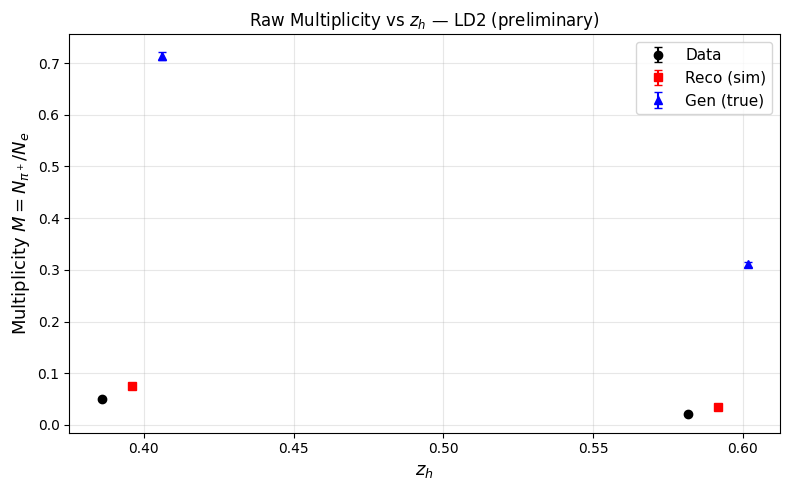

In [4]:
# =============================================================================
# PLOT 1: Raw multiplicity — Data vs Reco vs Gen
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

zh = df_acc['zh_mean']

ax.errorbar(zh - 0.01, df_acc['M_data'], yerr=df_acc['dM_data'],
            fmt='ko', label='Data',      capsize=3)
ax.errorbar(zh,        df_acc['M_reco'], yerr=df_acc['dM_reco'],
            fmt='rs', label='Reco (sim)', capsize=3)
ax.errorbar(zh + 0.01, df_acc['M_gen'],  yerr=df_acc['dM_gen'],
            fmt='b^', label='Gen (true)', capsize=3)

ax.set_xlabel(r'$z_h$', fontsize=13)
ax.set_ylabel(r'Multiplicity $M = N_{\pi^+}/N_e$', fontsize=13)
ax.set_title(r'Raw Multiplicity vs $z_h$ — LD2 (preliminary)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

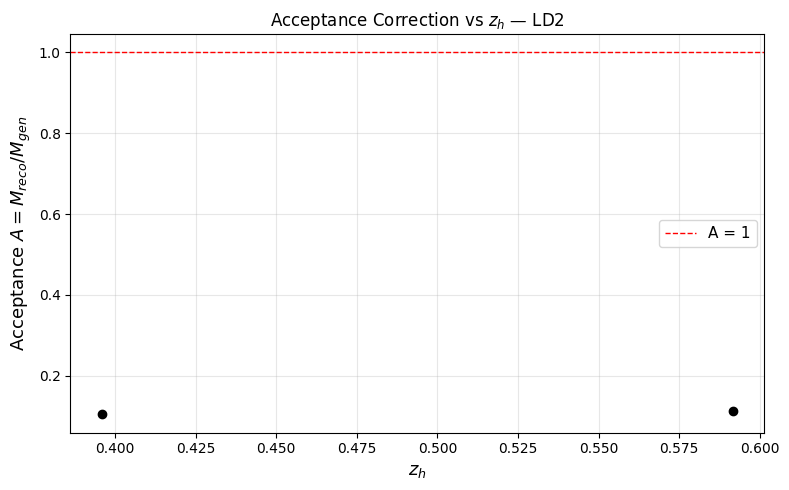

In [5]:
# =============================================================================
# PLOT 2: Acceptance A(zh) = M_reco / M_gen
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(df_acc['zh_mean'], df_acc['A'], yerr=df_acc['dA'],
            fmt='ko', capsize=3)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='A = 1')

ax.set_xlabel(r'$z_h$', fontsize=13)
ax.set_ylabel(r'Acceptance $A = M_{reco}/M_{gen}$', fontsize=13)
ax.set_title(r'Acceptance Correction vs $z_h$ — LD2', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

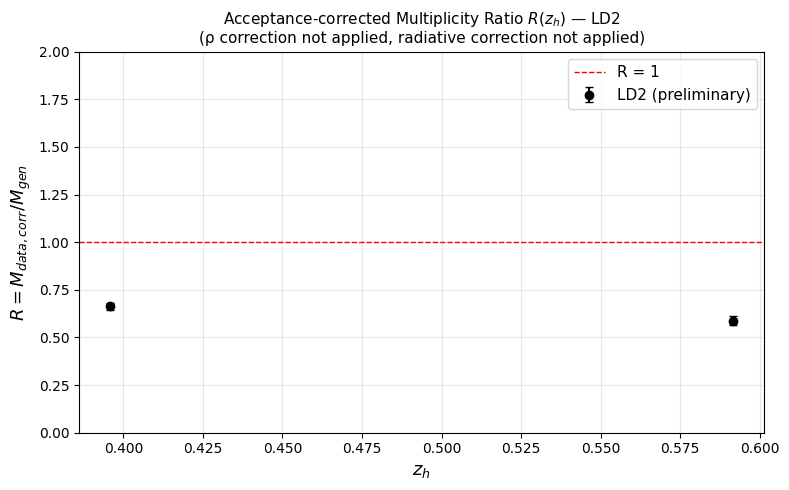

In [6]:
# =============================================================================
# PLOT 3: Acceptance-corrected multiplicity ratio R(zh)
# =============================================================================
# For LD2 only: R = M_data_corrected / M_gen
# Should be ~1 if simulation describes data well after acceptance correction.
# When C, Cu, Sn are added: R_A = M_data_A_corr / M_data_LD2_corr
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(df_acc['zh_mean'], df_acc['R'], yerr=df_acc['dR'],
            fmt='ko', capsize=3, label='LD2 (preliminary)')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='R = 1')

ax.set_xlabel(r'$z_h$', fontsize=13)
ax.set_ylabel(r'$R = M_{data,corr} / M_{gen}$', fontsize=13)
ax.set_title(
    r'Acceptance-corrected Multiplicity Ratio $R(z_h)$ — LD2' + '\n'
    r'(ρ correction not applied, radiative correction not applied)',
    fontsize=11)
ax.set_ylim(0, 2)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# SAVE ALL PLOTS TO PDF
# =============================================================================
PDF_PATH = os.path.join(
    '/Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code',
    '04_multiplicity_ratio.pdf')

zh = df_acc['zh_mean']

with PdfPages(PDF_PATH) as pdf:

    # Plot 1: Raw multiplicity
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(zh - 0.01, df_acc['M_data'], yerr=df_acc['dM_data'],
                fmt='ko', label='Data', capsize=3)
    ax.errorbar(zh,        df_acc['M_reco'], yerr=df_acc['dM_reco'],
                fmt='rs', label='Reco (sim)', capsize=3)
    ax.errorbar(zh + 0.01, df_acc['M_gen'],  yerr=df_acc['dM_gen'],
                fmt='b^', label='Gen (true)', capsize=3)
    ax.set_xlabel(r'$z_h$', fontsize=13)
    ax.set_ylabel(r'Multiplicity $M = N_{\pi^+}/N_e$', fontsize=13)
    ax.set_title(r'Raw Multiplicity vs $z_h$ — LD2 (preliminary)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); pdf.savefig(fig); plt.close()

    # Plot 2: Acceptance
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(zh, df_acc['A'], yerr=df_acc['dA'], fmt='ko', capsize=3)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='A = 1')
    ax.set_xlabel(r'$z_h$', fontsize=13)
    ax.set_ylabel(r'Acceptance $A = M_{reco}/M_{gen}$', fontsize=13)
    ax.set_title(r'Acceptance Correction vs $z_h$ — LD2')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); pdf.savefig(fig); plt.close()

    # Plot 3: R(zh)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(zh, df_acc['R'], yerr=df_acc['dR'],
                fmt='ko', capsize=3, label='LD2 (preliminary)')
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='R = 1')
    ax.set_xlabel(r'$z_h$', fontsize=13)
    ax.set_ylabel(r'$R = M_{data,corr} / M_{gen}$', fontsize=13)
    ax.set_title(
        r'Acceptance-corrected Multiplicity Ratio $R(z_h)$ — LD2' + '\n'
        r'(ρ correction not applied, radiative correction not applied)', fontsize=11)
    ax.set_ylim(0, 2)
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); pdf.savefig(fig); plt.close()

print(f'Saved → {PDF_PATH}')

Saved → /Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code/04_multiplicity_ratio.pdf
